<a href="https://colab.research.google.com/github/Yash433-sp/ecommerce-sales-analysis/blob/main/ecommerce_sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
orders = pd.read_csv("/content/drive/MyDrive/DA_P1/olist_orders_dataset.csv")
order_items = pd.read_csv("/content/drive/MyDrive/DA_P1/olist_order_items_dataset.csv")
products = pd.read_csv("/content/drive/MyDrive/DA_P1/olist_products_dataset.csv")
customers = pd.read_csv("/content/drive/MyDrive/DA_P1/olist_customers_dataset.csv")
payments = pd.read_csv("/content/drive/MyDrive/DA_P1/olist_order_payments_dataset.csv")

In [3]:
orders.shape


(99441, 8)

In [4]:
orders.dtypes

,0
order_id,object
customer_id,object
order_status,object
order_purchase_timestamp,object
order_approved_at,object
order_delivered_carrier_date,object
order_delivered_customer_date,object
order_estimated_delivery_date,object


In [5]:
orders.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [6]:
date_cols = [ "order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date", "order_estimated_delivery_date"]
for col in date_cols:
   orders[col] = pd.to_datetime(orders[col], errors="coerce")

In [7]:
orders[date_cols].dtypes

,0
order_purchase_timestamp,datetime64[ns]
order_approved_at,datetime64[ns]
order_delivered_carrier_date,datetime64[ns]
order_delivered_customer_date,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]


In [8]:
orders.duplicated().sum()

np.int64(0)

In [9]:
orders.drop_duplicates(inplace=True)

In [10]:
orders['order_approved_at'] = orders['order_approved_at'].fillna(orders['order_purchase_timestamp'])


In [11]:
# Keep nulls for canceled/unshipped orders
orders.loc[
    (orders['order_status'] == 'delivered') &
    (orders['order_delivered_carrier_date'].isnull()),
    'order_delivered_carrier_date'
] = orders['order_approved_at']

In [12]:
# Only for delivered orders
orders.loc[
    (orders['order_status'] == 'delivered') &
    (orders['order_delivered_customer_date'].isnull()),
    'order_delivered_customer_date'
] = orders['order_delivered_carrier_date']

In [13]:
orders['is_delivered'] = (orders['order_status'] == 'delivered').astype(int)
orders['is_canceled'] = (orders['order_status'] == 'canceled').astype(int)
orders['is_shipped'] = orders['order_delivered_carrier_date'].notnull().astype(int)

In [14]:
orders.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,1781
order_delivered_customer_date,2957
order_estimated_delivery_date,0
is_delivered,0
is_canceled,0


In [15]:
# Derived column 1 — order month (for monthly revenue trend)
orders['order_month'] = orders['order_purchase_timestamp'].dt.to_period('M')

# Derived column 2 — order year
orders['order_year'] = orders['order_purchase_timestamp'].dt.year

# Derived column 3 — order day of week (0=Monday, 6=Sunday)
orders['order_dayofweek'] = orders['order_purchase_timestamp'].dt.day_name()

# Derived column 4 — order hour (for peak hour analysis)
orders['order_hour'] = orders['order_purchase_timestamp'].dt.hour

# Derived column 5 — delivery days (how long delivery took)
orders['delivery_days'] = (
    orders['order_delivered_customer_date'] -
    orders['order_purchase_timestamp']
).dt.days


orders[['order_month','order_year','order_dayofweek','order_hour','delivery_days']].head(10)

,order_month,order_year,order_dayofweek,order_hour,delivery_days
0,2017-10,2017,Monday,10,8.0
1,2018-07,2018,Tuesday,20,13.0
2,2018-08,2018,Wednesday,8,9.0
3,2017-11,2017,Saturday,19,13.0
4,2018-02,2018,Tuesday,21,2.0
5,2017-07,2017,Sunday,21,16.0
6,2017-04,2017,Tuesday,12,NaN
7,2017-05,2017,Tuesday,13,9.0
8,2017-01,2017,Monday,18,9.0
9,2017-07,2017,Saturday,11,18.0


In [16]:
print("New columns added:", ['order_month','order_year','order_dayofweek','order_hour','delivery_days'])
print("Negative delivery days:", (orders['delivery_days'] < 0).sum())  # should be 0
print("Null delivery days:", orders['delivery_days'].isnull().sum())   # will have some — expected
print("orders shape:", orders.shape)

New columns added: ['order_month', 'order_year', 'order_dayofweek', 'order_hour', 'delivery_days']
Negative delivery days: 0
Null delivery days: 2957
orders shape: (99441, 16)


In [17]:

orders.to_csv('orders_clean.csv', index=False)
print("Saved! Shape:", orders.shape)
print("Columns:", list(orders.columns))

Saved! Shape: (99441, 16)
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'is_delivered', 'is_canceled', 'is_shipped', 'order_month', 'order_year', 'order_dayofweek', 'order_hour', 'delivery_days']


In [18]:
df = orders.merge(order_items, on='order_id', how='left')
df = df.merge(products, on='product_id', how='left')
df = df.merge(customers, on='customer_id', how='left')
print("Master dataframe shape:", df.shape)
df.head()

Master dataframe shape: (113425, 34)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_delivered,is_canceled,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,0,...,268.0,4.0,500.0,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,0,...,178.0,1.0,400.0,19.0,13.0,19.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,0,...,232.0,1.0,420.0,24.0,19.0,21.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,0,...,468.0,3.0,450.0,30.0,10.0,20.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,0,...,316.0,4.0,250.0,51.0,15.0,15.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [19]:

print(df.isnull().sum()[df.isnull().sum() > 0])


df = df[df['price'] > 0]


df['product_category_name'] = df['product_category_name'].fillna('unknown')

print("Final shape:", df.shape)
df.to_csv('master_clean.csv', index=False)

order_delivered_carrier_date     1966
order_delivered_customer_date    3221
delivery_days                    3221
order_item_id                     775
product_id                        775
seller_id                         775
shipping_limit_date               775
price                             775
freight_value                     775
product_category_name            2378
product_name_lenght              2378
product_description_lenght       2378
product_photos_qty               2378
product_weight_g                  793
product_length_cm                 793
product_height_cm                 793
product_width_cm                  793
dtype: int64
Final shape: (112650, 34)


In [20]:

df = df.dropna(subset=['price', 'freight_value', 'product_id'])\

df['product_category_name'] = df['product_category_name'].fillna('unknown')

cols_to_drop = ['product_name_lenght', 'product_description_lenght',
                'product_photos_qty', 'product_weight_g',
                'product_length_cm', 'product_height_cm', 'product_width_cm']
df = df.drop(columns=cols_to_drop)
print("Remaining nulls:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nFinal shape:", df.shape)

Remaining nulls:
order_delivered_carrier_date     1192
order_delivered_customer_date    2446
delivery_days                    2446
dtype: int64

Final shape: (112650, 27)


## Data Cleaning Summary

| Step | Action | Result |
|------|--------|--------|
| orders | Fixed date types, added derived columns | 99,441 rows, 16 cols |
| order_items | Dropped rows with missing price/product_id | Removed 775 nulls |
| products | Filled missing category with 'unknown', dropped dimension cols | Removed 2,378 nulls |
| master merge | Joined orders + order_items + products + customers | 112,650 rows, 27 cols |

In [21]:
df.to_csv('master_clean.csv', index=False)
print("Shape:", df.shape)
print("Columns:", list(df.columns))

Shape: (112650, 27)
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'is_delivered', 'is_canceled', 'is_shipped', 'order_month', 'order_year', 'order_dayofweek', 'order_hour', 'delivery_days', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']


In [22]:

df = pd.read_csv('master_clean.csv')


df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

print("Loaded:", df.shape)
df.head(3)

Loaded: (112650, 27)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_delivered,is_canceled,...,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,0,...,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,0,...,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,0,...,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO


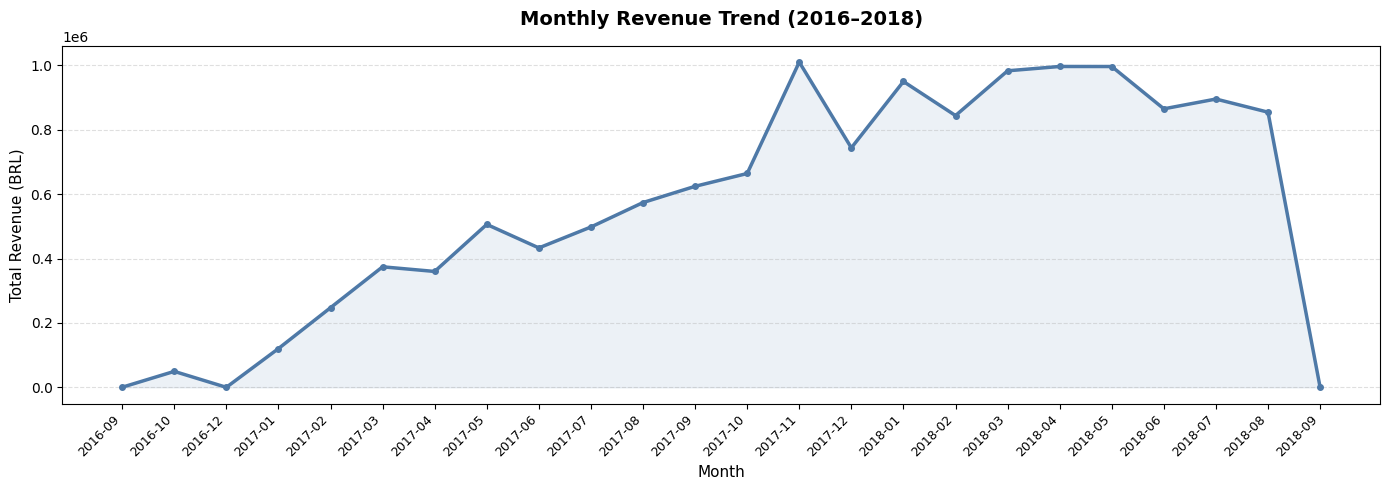

Peak month: 2017-11
Peak revenue: 1010271.37


In [23]:
# Q1 — Monthly Revenue Trend
monthly_revenue = df.groupby('order_month')['price'].sum().reset_index()
monthly_revenue.columns = ['month', 'revenue']
monthly_revenue['month'] = monthly_revenue['month'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly_revenue['month'], monthly_revenue['revenue'],
         color='#4e79a7', linewidth=2.5, marker='o', markersize=4)

plt.fill_between(range(len(monthly_revenue)), monthly_revenue['revenue'],
                 alpha=0.1, color='#4e79a7')

plt.xticks(range(len(monthly_revenue)), monthly_revenue['month'],
           rotation=45, ha='right', fontsize=9)
plt.title('Monthly Revenue Trend (2016–2018)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=11)
plt.ylabel('Total Revenue (BRL)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('q1_monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

print("Peak month:", monthly_revenue.loc[monthly_revenue['revenue'].idxmax(), 'month'])
print("Peak revenue:", monthly_revenue['revenue'].max())

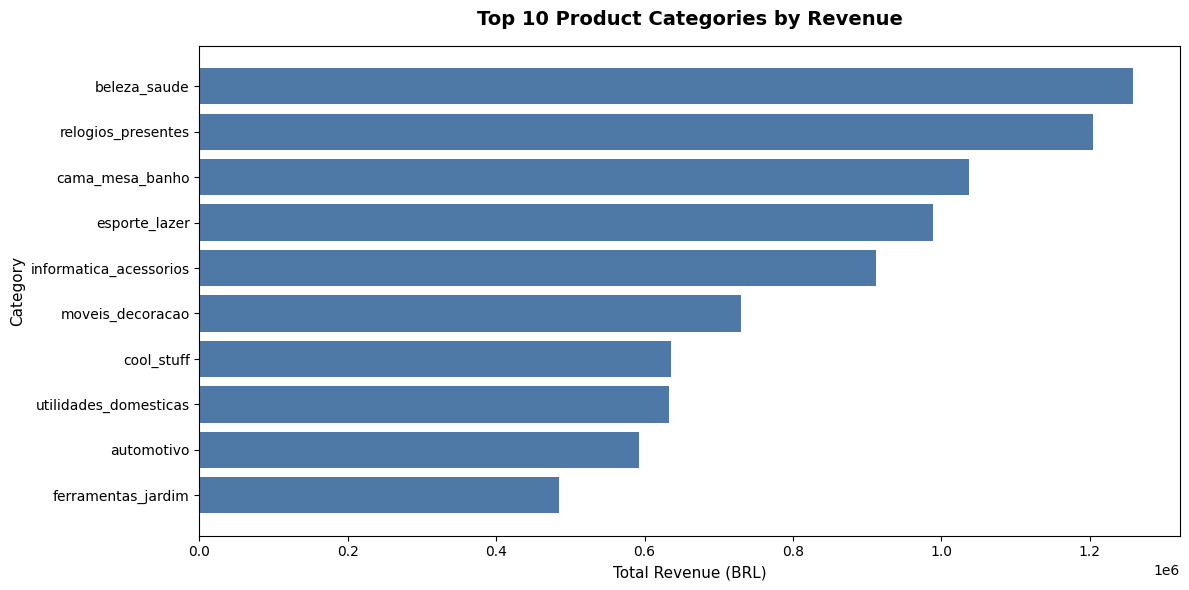

Top 3 categories by revenue:
          category    revenue
      beleza_saude 1258681.34
relogios_presentes 1205005.68
   cama_mesa_banho 1036988.68


In [24]:
# Q2 — Which product categories make the most revenue?


category_revenue = df.groupby('product_category_name')['price'].sum()


category_revenue = category_revenue.sort_values(ascending=False).head(10)


category_revenue = category_revenue.round(2).reset_index()
category_revenue.columns = ['category', 'revenue']


plt.figure(figsize=(12, 6))
plt.barh(category_revenue['category'], category_revenue['revenue'], color='#4e79a7')
plt.title('Top 10 Product Categories by Revenue', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Revenue (BRL)', fontsize=11)
plt.ylabel('Category', fontsize=11)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('q2_category_revenue.png', dpi=150, bbox_inches='tight')
plt.show()


print("Top 3 categories by revenue:")
print(category_revenue.head(3).to_string(index=False))

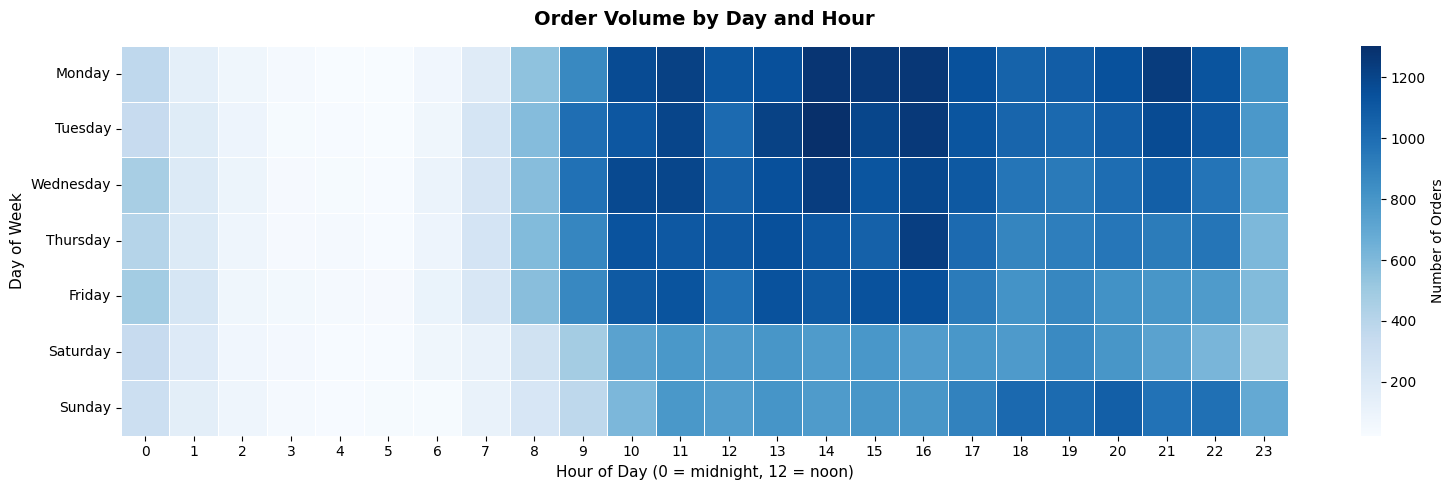

Busiest day: Tuesday
Busiest hour: 14:00
Orders in that slot: 1304


In [25]:
# Q3 — At what days and hours do most orders happen?


df['order_hour'] = df['order_purchase_timestamp'].dt.hour
df['order_dayofweek'] = df['order_purchase_timestamp'].dt.day_name()


heatmap_data = df.groupby(['order_dayofweek', 'order_hour'])['order_id'].count().reset_index()
heatmap_data.columns = ['day', 'hour', 'order_count']


heatmap_pivot = heatmap_data.pivot(index='day', columns='hour', values='order_count')


day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_pivot = heatmap_pivot.reindex(day_order)


plt.figure(figsize=(16, 5))
sns.heatmap(heatmap_pivot,
            cmap='Blues',
            linewidths=0.5,
            annot=False,
            fmt='.0f',
            cbar_kws={'label': 'Number of Orders'})

plt.title('Order Volume by Day and Hour', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hour of Day (0 = midnight, 12 = noon)', fontsize=11)
plt.ylabel('Day of Week', fontsize=11)
plt.tight_layout()
plt.savefig('q3_order_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


peak = heatmap_data.loc[heatmap_data['order_count'].idxmax()]
print(f"Busiest day: {peak['day']}")
print(f"Busiest hour: {peak['hour']}:00")
print(f"Orders in that slot: {peak['order_count']}")

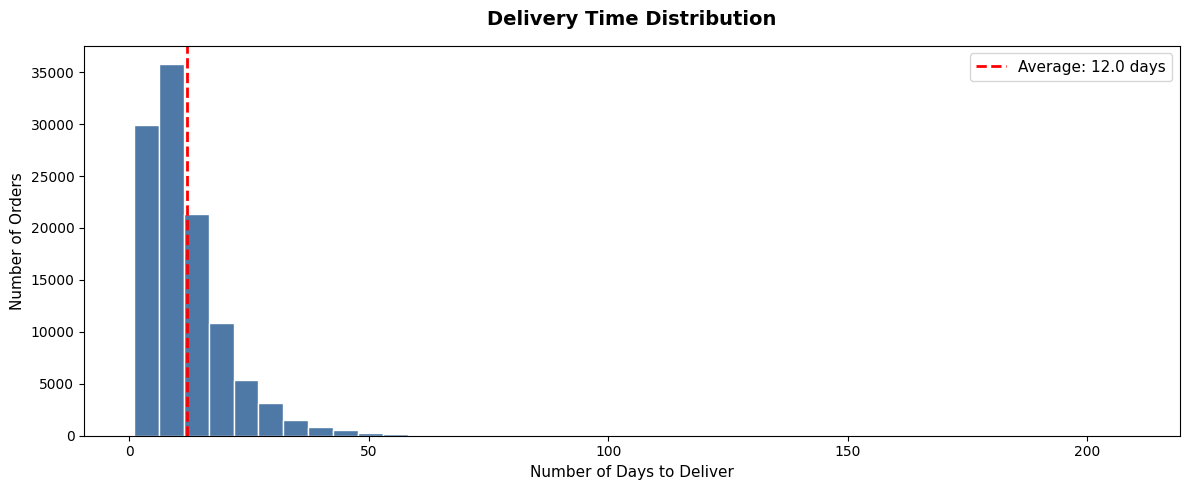

Average delivery time : 12.0 days
Fastest delivery      : 1.0 days
Slowest delivery      : 209.0 days
50% of orders arrive within : 10 days


In [26]:
# Q4 — How long does delivery take?


delivered_df = df.dropna(subset=['delivery_days'])

delivered_df = delivered_df[delivered_df['delivery_days'] > 0]

plt.figure(figsize=(12, 5))
plt.hist(delivered_df['delivery_days'], bins=40, color='#4e79a7', edgecolor='white')

avg_days = delivered_df['delivery_days'].mean()
plt.axvline(avg_days, color='red', linestyle='--', linewidth=2, label=f'Average: {avg_days:.1f} days')

plt.title('Delivery Time Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Days to Deliver', fontsize=11)
plt.ylabel('Number of Orders', fontsize=11)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('q4_delivery_time.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Average delivery time : {delivered_df['delivery_days'].mean():.1f} days")
print(f"Fastest delivery      : {delivered_df['delivery_days'].min()} days")
print(f"Slowest delivery      : {delivered_df['delivery_days'].max()} days")
print(f"50% of orders arrive within : {delivered_df['delivery_days'].median():.0f} days")

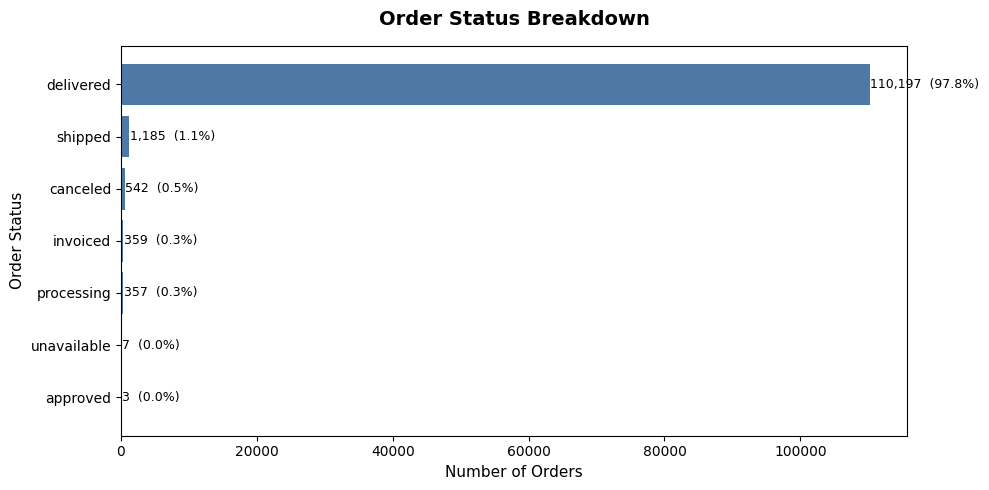

Order status summary:
     status  count  percentage
  delivered 110197        97.8
    shipped   1185         1.1
   canceled    542         0.5
   invoiced    359         0.3
 processing    357         0.3
unavailable      7         0.0
   approved      3         0.0


In [27]:
# Q5 — What is the breakdown of order statuses?

status_counts = df['order_status'].value_counts().reset_index()
status_counts.columns = ['status', 'count']

status_counts['percentage'] = (status_counts['count'] / status_counts['count'].sum() * 100).round(1)

plt.figure(figsize=(10, 5))
bars = plt.barh(status_counts['status'], status_counts['count'], color='#4e79a7')

for i, row in status_counts.iterrows():
    plt.text(row['count'] + 100, i,
             f"{row['count']:,}  ({row['percentage']}%)",
             va='center', fontsize=9)

plt.title('Order Status Breakdown', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Orders', fontsize=11)
plt.ylabel('Order Status', fontsize=11)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('q5_order_status.png', dpi=150, bbox_inches='tight')
plt.show()

print("Order status summary:")
print(status_counts.to_string(index=False))

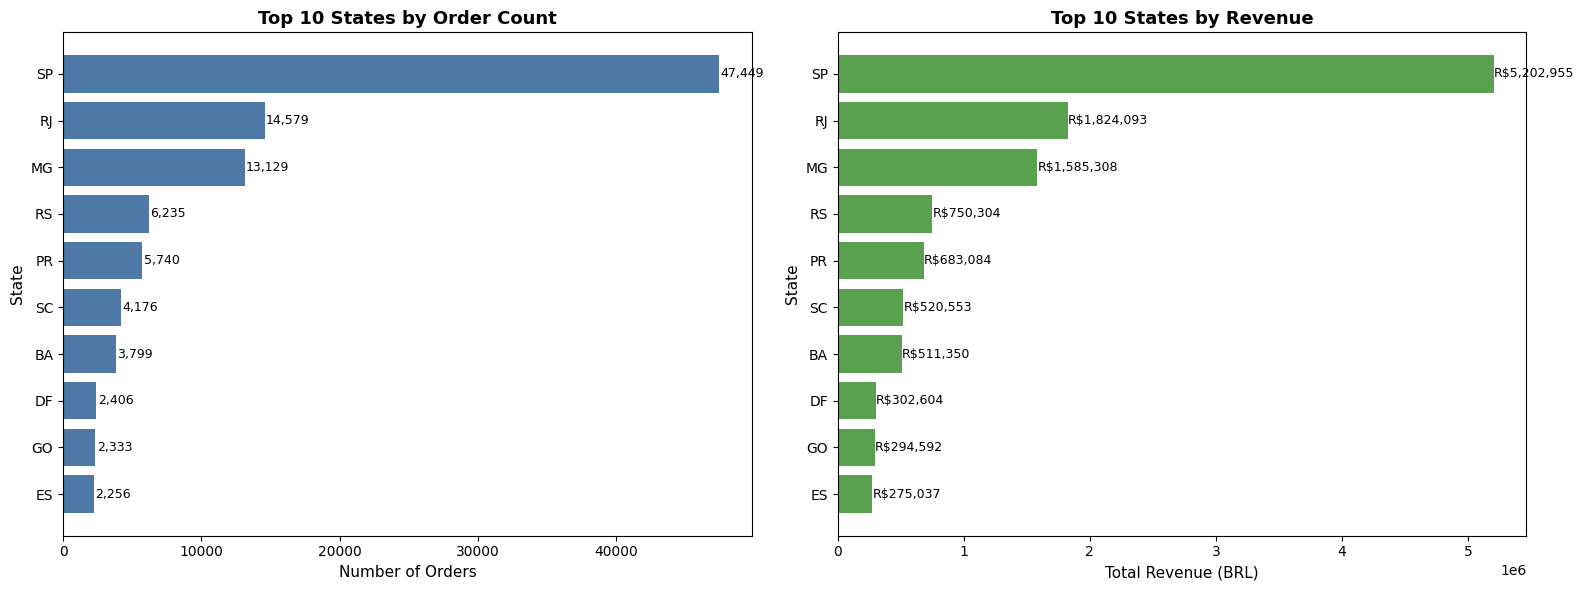

Top 5 states by orders:
state  order_count    revenue
   SP        47449 5202955.05
   RJ        14579 1824092.67
   MG        13129 1585308.03
   RS         6235  750304.02
   PR         5740  683083.76


In [28]:
# Q6 — Which states place the most orders?

state_orders = df.groupby('customer_state')['order_id'].count().reset_index()
state_orders.columns = ['state', 'order_count']

state_orders = state_orders.sort_values('order_count', ascending=False).head(10)

state_revenue = df.groupby('customer_state')['price'].sum().round(2).reset_index()
state_revenue.columns = ['state', 'revenue']

state_df = state_orders.merge(state_revenue, on='state')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))


ax1.barh(state_df['state'], state_df['order_count'], color='#4e79a7')
ax1.set_title('Top 10 States by Order Count', fontsize=13, fontweight='bold')
ax1.set_xlabel('Number of Orders', fontsize=11)
ax1.set_ylabel('State', fontsize=11)
ax1.invert_yaxis()
for i, val in enumerate(state_df['order_count']):
    ax1.text(val + 100, i, f'{val:,}', va='center', fontsize=9)

ax2.barh(state_df['state'], state_df['revenue'], color='#59a14f')
ax2.set_title('Top 10 States by Revenue', fontsize=13, fontweight='bold')
ax2.set_xlabel('Total Revenue (BRL)', fontsize=11)
ax2.set_ylabel('State', fontsize=11)
ax2.invert_yaxis()
for i, val in enumerate(state_df['revenue']):
    ax2.text(val + 1000, i, f'R${val:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('q6_top_states.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 states by orders:")
print(state_df[['state','order_count','revenue']].head(5).to_string(index=False))

## Key Business Insights

1. **Seasonality** — November 2017 was the peak revenue month (R$1,010,271)
   driven by Black Friday. Q4 planning should prioritise stock for this period.

2. **Top categories** — Beauty & Health, Watches, and Bed & Bath
   contribute the most revenue. Marketing spend should focus here.

3. **Peak ordering window** — Tuesday afternoons (2PM) see highest order volume.
   Ideal time to send promotional emails or push notifications.

4. **Delivery performance** — Average delivery is 12 days with some extreme
   outliers (209 days). Logistics improvement could boost customer satisfaction.

5. **Geographic concentration** — São Paulo alone accounts for 42% of all orders.
   Expanding fulfilment centres in RJ and MG could reduce delivery times there.

In [29]:

from google.colab import files
files.download('master_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:

df['order_month_num'] = df['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()
df['order_month_label'] = df['order_purchase_timestamp'].dt.strftime('%Y-%m')


df.to_csv('master_clean.csv', index=False)
files.download('master_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
from google.colab import files

charts = ['q1_monthly_revenue.png', 'q2_category_revenue.png',
          'q3_order_heatmap.png', 'q4_delivery_time.png',
          'q5_order_status.png', 'q6_top_states.png']

for chart in charts:
    files.download(chart)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>